In [12]:
!pip install onnxruntime opencv-python matplotlib

  Using cached coloredlogs-15.0.1-py2.py3-none-any.whl.metadata (12 kB)
  Using cached humanfriendly-10.0-py2.py3-none-any.whl.metadata (9.2 kB)
  Using cached pyreadline3-3.5.4-py3-none-any.whl.metadata (4.7 kB)
   ---------------------------------------- 0.0/13.5 MB ? eta -:--:--
   --- ------------------------------------ 1.0/13.5 MB 8.4 MB/s eta 0:00:02
   ------- -------------------------------- 2.6/13.5 MB 7.6 MB/s eta 0:00:02
   ------------ --------------------------- 4.2/13.5 MB 7.2 MB/s eta 0:00:02
   ----------------- ---------------------- 5.8/13.5 MB 7.3 MB/s eta 0:00:02
   ---------------------- ----------------- 7.6/13.5 MB 7.8 MB/s eta 0:00:01
   ------------------------------ --------- 10.2/13.5 MB 8.5 MB/s eta 0:00:01
   ----------------------------------- ---- 11.8/13.5 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------  13.4/13.5 MB 8.6 MB/s eta 0:00:01
   ---------------------------------------- 13.5/13.5 MB 8.1 MB/s  0:00:01
Using cached coloredlog


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import os
import numpy as np
import pandas as pd 
import random
import cv2
import matplotlib.pyplot as plt
import keras.backend as K
from keras.models import Model, Sequential
from keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from keras.layers import Conv2D, SeparableConv2D, MaxPool2D, LeakyReLU, Activation
from keras.optimizers import Adam
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.layers import Conv2D, SeparableConv2D, MaxPool2D
from tensorflow.keras.models import Model
from IPython.display import clear_output
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.layers import Activation
from tensorflow.keras.utils import get_custom_objects
from tensorflow.keras.utils import custom_object_scope
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dropout
import efficientnet.tfkeras

In [2]:
def predict_and_visualize_pn(image_path, model, img_dims=150,
                          weights_path='best_weights_pn.hdf5', show=True):

    import tensorflow as tf
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    model.load_weights(weights_path)

    # Load & preprocess image
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError('Image not found: ' + image_path)

    orig = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    img_resized = cv2.resize(img, (img_dims, img_dims))
    x = np.stack([img_resized]*3, axis=-1).astype('float32') / 255.0
    x = np.expand_dims(x, axis=0)

    # Prediction
    prob = float(model.predict(x)[0][0])
    label = 'PNEUMONIA' if prob >= 0.5 else 'NORMAL'
    print(f'Pneumonia probability: {prob:.4f} — Predicted: {label}')

    # --------------------------------------------------
    # ✅ FIX 1: Explicitly find last convolutional layer
    # --------------------------------------------------
    last_conv_layer = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.SeparableConv2D):
            last_conv_layer = layer.name
            break

    if last_conv_layer is None:
        raise RuntimeError("No SeparableConv2D layer found for Grad-CAM.")

    print(f"Using Grad-CAM layer: {last_conv_layer}")

    # --------------------------------------------------
    # Grad-CAM computation
    # --------------------------------------------------
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(x)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    # Global average pooling of gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature maps
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    # Normalize
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    heatmap = heatmap.numpy()

    # Resize to original image
    heatmap = cv2.resize(heatmap, (orig.shape[1], orig.shape[0]))
    heatmap = np.uint8(255 * heatmap)

    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(orig, 0.6, heatmap_color, 0.4, 0)

    if show:
        plt.figure(figsize=(6, 6))
        plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        plt.axis('off')
        plt.title(f'Pred: {label} ({prob:.2f})')
        plt.show()

    return prob, label, overlay


def build_model_pn(weights, img_dims=150):
    inputs = Input(shape=(img_dims, img_dims, 3))

    x = Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same')(inputs)
    x = Conv2D(filters=16, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = MaxPool2D(pool_size=(2, 2))(x)

    x = SeparableConv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = SeparableConv2D(filters=32, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPool2D(pool_size=(2, 2))(x)

    x = SeparableConv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = SeparableConv2D(filters=64, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPool2D(pool_size=(2, 2))(x)

    x = SeparableConv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = SeparableConv2D(filters=128, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPool2D(pool_size=(2, 2))(x)
    x = Dropout(rate=0.2)(x)

    x = SeparableConv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = SeparableConv2D(filters=256, kernel_size=(3, 3), activation='relu', padding='same')(x)
    x = BatchNormalization()(x)
    x = MaxPool2D(pool_size=(2, 2))(x)
    x = Dropout(rate=0.2)(x)

    x = Flatten()(x)
    x = Dense(units=512, activation='relu')(x)
    x = Dropout(rate=0.7)(x)
    x = Dense(units=128, activation='relu')(x)
    x = Dropout(rate=0.5)(x)
    x = Dense(units=64, activation='relu')(x)
    x = Dropout(rate=0.3)(x)

    output = Dense(units=1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=output)
    model.load_weights(weights)
    return model

pn_model = build_model_pn('best_weights_pn.hdf5')

def infer_pneumonia(image_path):
    predict_and_visualize_pn(image_path, pn_model, img_dims=150)

In [3]:
import os
import time
import numpy as np
import cv2
import onnxruntime
import matplotlib.pyplot as plt

from matplotlib.colors import TABLEAU_COLORS

def color_list():
    def hex2rgb(h):
        return tuple(int(h[1 + i:1 + i + 2], 16) for i in (0, 2, 4))
    return [hex2rgb(h) for h in TABLEAU_COLORS.values()]

colors = color_list()

def xyxy2xywh(bbox, H, W):
    x1, y1, x2, y2 = bbox
    return [0.5*(x1+x2)/W, 0.5*(y1+y2)/H, (x2-x1)/W, (y2-y1)/H]

def load_img(img_file, img_mean=0, img_scale=1/255):
    """
    Read image, convert to RGB, resize to (640,640), normalize and transpose to (1,3,640,640)
    """
    img = cv2.imread(img_file)  # BGR
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_file}")
    img = img[:, :, ::-1]  # BGR->RGB
    img = cv2.resize(img, (640, 640), interpolation=cv2.INTER_LINEAR)
    img = (img - img_mean) * img_scale
    img = np.asarray(img, dtype=np.float32)
    img = np.expand_dims(img, 0)
    img = img.transpose(0, 3, 1, 2)
    return img

def model_inference(model_path, image_np, device="cpu"):
    """
    Run ONNX model and return raw detections in same layout as original repo.
    """
    providers = ['CUDAExecutionProvider'] if device == "cuda" else ['CPUExecutionProvider']
    session = onnxruntime.InferenceSession(model_path, providers=providers)
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name
    output = session.run([output_name], {input_name: image_np})
    return output[0][:, :6]

def post_process(img_file, output, score_threshold=0.3, format="xywh"):
    """
    Draw bounding boxes on the input image and return (image_bgr, annotation_text)
    """
    assert format == "xyxy" or format == "xywh"
    det_bboxes, det_scores, det_labels = output[:, 0:4], output[:, 4], output[:, 5]
    id2names = {
        0: "boneanomaly", 1: "bonelesion", 2: "foreignbody",
        3: "fracture", 4: "metal", 5: "periostealreaction",
        6: "pronatorsign", 7: "softtissue", 8: "text"
    }

    img = cv2.imread(img_file)  # keep BGR for drawing
    if img is None:
        raise FileNotFoundError(f"Image not found: {img_file}")
    H, W = img.shape[:2]
    h, w = 640, 640
    label_txt = ""

    for idx in range(len(det_bboxes)):
        if det_scores[idx] > score_threshold:
            bbox = det_bboxes[idx]
            bbox = bbox @ np.array([[W/w, 0, 0, 0],
                                    [0, H/h, 0, 0],
                                    [0, 0, W/w, 0],
                                    [0, 0, 0, H/h]])
            bbox_int = [int(x) for x in bbox]
            label = int(det_labels[idx])

            if format == "xywh":
                bbox_xywh = xyxy2xywh(bbox, H, W)
                bbox_for_text = bbox_xywh
            else:
                bbox_for_text = bbox

            label_txt += f"{label} {det_scores[idx]:.5f} {bbox_for_text[0]:.5f} {bbox_for_text[1]:.5f} {bbox_for_text[2]:.5f} {bbox_for_text[3]:.5f}\n"

            color_map = colors[label]
            txt = f"{id2names.get(label, label)} {det_scores[idx]:.2f}"
            (text_width, text_height), _ = cv2.getTextSize(txt, cv2.FONT_HERSHEY_SIMPLEX, 0.5, 2)

            cv2.rectangle(img, (bbox_int[0], bbox_int[1]), (bbox_int[2], bbox_int[3]), color_map, 2)
            cv2.rectangle(img, (bbox_int[0]-2, bbox_int[1]-text_height-10),
                          (bbox_int[0] + text_width+2, bbox_int[1]), color_map, -1)
            cv2.putText(img, txt, (bbox_int[0], bbox_int[1]-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)

    return img, label_txt

def run_inference_fr(img_path, model_path='yolov7-p6-bonefracture.onnx', device='cpu', score_threshold=0.3, bbox_format='xywh', show=True):
    """
    All-in-one notebook method:
      - runs model on `img_path` using `model_path`
      - prints annotation text
      - displays the annotated image inline (if show=True)
    Returns (annotated_image_bgr, annotation_text)
    """
    # Validate paths
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model not found: {model_path}")
    if not os.path.exists(img_path):
        raise FileNotFoundError(f"Image not found: {img_path}")

    # Load, infer, post-process
    img_np = load_img(img_path)
    t0 = time.time()
    out = model_inference(model_path, img_np, device=device)
    t1 = time.time()
    out_img, out_txt = post_process(img_path, out, score_threshold=score_threshold, format=bbox_format)

    print(f"Inference + postprocess completed in {t1 - t0:.3f} secs.")
    print("Annotations:")
    print(out_txt)

    if show:
        plt.figure(figsize=(10,10))
        plt.imshow(out_img[..., ::-1])  # BGR->RGB for display
        plt.axis('off')
        plt.show()

    return out_img, out_txt

# Example usage (edit paths then run):
# model = "yolov7-p6-bonefracture.onnx"
# image = "../images/your_test_image.jpg"  # or "images/your_test_image.jpg"
# out_img, out_txt = run_inference_display(model, image, device='cpu', score_threshold=0.3, bbox_format='xywh', show=True)

In [4]:
# Cataract
# Path to your trained model
MODEL_PATH = "efficen_model_2.h5"   # change if needed


def swish(x):
    return x * tf.nn.sigmoid(x)

def mish(x):
    return x * tf.math.tanh(tf.math.softplus(x))


class FixedDropout(Dropout):
    def _get_noise_shape(self, inputs):
        if self.noise_shape is None:
            return None
        symbolic_shape = tf.shape(inputs)
        noise_shape = [
            symbolic_shape[axis] if shape is None else shape
            for axis, shape in enumerate(self.noise_shape)
        ]
        return tuple(noise_shape)

with custom_object_scope({
    "swish": swish,
    "mish": mish,
    "FixedDropout": FixedDropout
}):
    model = load_model(MODEL_PATH, compile=False)

model.summary()


# Correct image size (from your training code)
IMG_HEIGHT = 192
IMG_WIDTH = 256

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img_array




def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv"):

    # Extract backbone
    backbone = model.get_layer("efficientnet-b0")

    # Create a model that gives last conv output
    conv_model = tf.keras.Model(
        backbone.input,
        backbone.get_layer(last_conv_layer_name).output
    )

    # Forward pass through backbone only
    with tf.GradientTape() as tape:

        # Pass input through backbone
        conv_outputs = conv_model(img_array)
        tape.watch(conv_outputs)

        # Now manually pass through remaining layers
        x = conv_outputs
        x = model.layers[2](x)  # GlobalAveragePooling2D
        predictions = model.layers[3](x)  # Dense

        loss = predictions[:, 0]

    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8

    return heatmap.numpy()



def overlay_gradcam(img_path, heatmap, alpha=0.4):
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    
    superimposed_img = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    
    return img, superimposed_img




def infer_cataract(img_path):
    img_array = preprocess_image(img_path)
    img_array = tf.convert_to_tensor(img_array)

    # Get predictions for both classes [no_cataract_prob, cataract_prob]
    probs = model.predict(img_array)[0]
    no_cataract_prob = float(probs[0])
    cataract_prob = float(probs[1])

    print("Normal Probability:", no_cataract_prob)
    print("Cataract Probability:", cataract_prob)

    if cataract_prob > no_cataract_prob:
        print("Prediction: Cataract Detected")
    else:
        print("Prediction: Normal Eye")

    heatmap = make_gradcam_heatmap(img_array, model)

    original, gradcam_image = overlay_gradcam(img_path, heatmap)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.title("Original Image")
    plt.imshow(original)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Grad-CAM")
    plt.imshow(gradcam_image)
    plt.axis("off")

    plt.show()



Model: "functional_49"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 192, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnet-b0 (Functional)         │ (None, 6, 8, 1280)          │       4,049,564 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 2)                   │           2,562 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,052,126 (15.46 MB)

 Trainable params: 4,010,110 (15.30 MB)

 Non-trainable params: 42,016 (164.12 KB)

In [5]:
def run_test():
    image_path = input("Enter image path: ").strip()

    print("\nChoose an option:")
    print("1. Test Pneumonia")
    print("2. Test Fracture")
    print("3. Test Cataract")

    choice = input("Enter Option: ").strip()

    if choice == "1":
        infer_pneumonia(image_path)
    elif choice == "2":
        run_inference_fr(image_path)
    elif choice == "3":
        infer_cataract(image_path)
    else:
        print("Invalid choice. Please enter 1 or 2 or 3.")

Enter image path:  ./test/pn_2.jpeg



Choose an option:
1. Test Pneumonia
2. Test Fracture
3. Test Cataract


Enter Option:  1


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
Pneumonia probability: 1.0000 — Predicted: PNEUMONIA
Using Grad-CAM layer: separable_conv2d_7


C:\Users\KIIT\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 150, 150, 3))
  warnings.warn(msg)


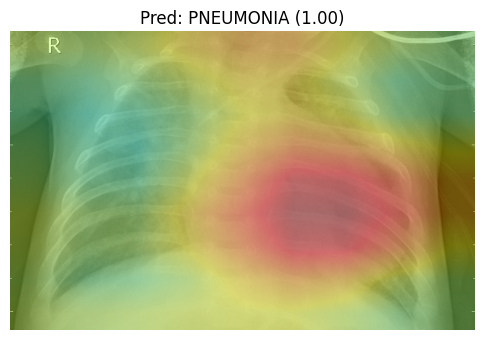

In [ ]:
while True:
    run_test()

    again = input("\nDo you want to test more? (y/n): ").strip().lower()
    
    if again == "y":
        clear_output(wait=True)
    else:
        print("Exiting...")
        break